In [1]:
%matplotlib inline
import os
import tempfile

import scipy.stats as st

import pyabc

pyabc.settings.set_figure_params('pyabc')  # for beautified plots

In [3]:
import numpy as np
import pandas as pd
import joblib

def extract_features(data):
    """extract statistical features from time distributions
       Input data shape: (n_samples, n_timepoints)
    """
    n_features = data.shape[1]

    mean = np.mean(data, axis=1, keepdims=True)
    std = np.std(data, axis=1, keepdims=True)
    cv = std / (mean + 1e-10)  # avoid /0
    max_ = np.max(data, axis=1, keepdims=True)

    percentile25 = np.percentile(data, 25, axis=1, keepdims=True)
    percentile50 = np.percentile(data, 50, axis=1, keepdims=True)
    percentile75 = np.percentile(data, 75, axis=1, keepdims=True)

    prop_gt1 = np.sum(data > 1, axis=1, keepdims=True) / n_features
    prop_gt2 = np.sum(data > 2, axis=1, keepdims=True) / n_features
    prop_gt3 = np.sum(data > 3, axis=1, keepdims=True) / n_features

    features = np.hstack([
        mean, std, cv, max_, prop_gt1, prop_gt2, prop_gt3,
        percentile25, percentile50, percentile75
    ])
    return features

#ml_rev23 = np.load("../synthetic_data/svm/ABC/ml_rev23_abc.npz")
ml_rev23 = np.load("../../synthetic_data/svm/bd/ml_rev23_40.npz")

df = pd.read_csv("../../synthetic_data/svm/bd/results/test_labels_linear.csv")

test_idx = df["global_idx"].to_numpy()
train_idx = np.setdiff1d(np.arange(0, ml_rev23['label'].shape[0]), test_idx) # get train and test indices

xmat_f = extract_features(ml_rev23['xmat'].T) # xmat after extract features
labels_all = ml_rev23['label'] # all true labales

In [4]:
%%time

%run -i abc_smc.py # Use -i so the script runs in the current notebook’s namespace

ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-11 14:40:59>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 1.58774123e+00.
ABC INFO: Accepted: 100 / 286 = 3.4965e-01, ESS: 1.0000e+02.
ABC INFO: t: 1, eps: 5.72045848e-01.
ABC INFO: Accepted: 100 / 614 = 1.6287e-01, ESS: 9.7822e+01.
ABC INFO: t: 2, eps: 3.68794891e-01.
ABC INFO: Accepted: 100 / 1352 = 7.3964e-02, ESS: 9.9169e+01.
ABC INFO: t: 3, eps: 2.57221482e-01.
ABC INFO: Accepted: 100 / 3510 = 2.8490e-02, ESS: 9.8198e+01.
ABC INFO: t: 4, eps: 1.78908739e-01.
ABC INFO: Accepted: 100 / 8263 = 1.2102e-02, ESS: 9.9877e+01.
ABC INFO: t: 5, eps: 1.42770121e-01.
ABC INFO: Accepted: 100 / 24523 = 4.0778e-03, ESS: 9.9993e+01.
ABC INFO: Stop: Maximum number of generations.
ABC.History INFO: Done <ABCSMC id=1, duration=0:00:33.153717, end_time=2026-03-11 14:41:33>
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-11 14:41:33>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 1.77021044e+00.


[t=0] eps=1.588 acc=34.9650% p=[0.69 0.31]
[t=1] eps=0.572 acc=16.2866% p=[0.62098828 0.37901172]  dp=0.06901
[t=2] eps=0.3688 acc=7.3964% p=[0.66845263 0.33154737]  dp=0.04746
[t=3] eps=0.2572 acc=2.8490% p=[0.5439211 0.4560789]  dp=0.1245
[t=4] eps=0.1789 acc=1.2102% p=[0.51245782 0.48754218]  dp=0.03146
[STOP] Chosen t=4: acc<0.05 and dp<0.05 for 1 consecutive pops.


ABC INFO: Accepted: 100 / 262 = 3.8168e-01, ESS: 1.0000e+02.
ABC INFO: t: 1, eps: 8.94831898e-01.
ABC INFO: Accepted: 100 / 658 = 1.5198e-01, ESS: 9.9633e+01.
ABC INFO: t: 2, eps: 5.92037604e-01.
ABC INFO: Accepted: 100 / 1613 = 6.1996e-02, ESS: 9.8374e+01.
ABC INFO: t: 3, eps: 4.18916774e-01.
ABC INFO: Accepted: 100 / 3734 = 2.6781e-02, ESS: 9.9508e+01.
ABC INFO: t: 4, eps: 3.16715439e-01.
ABC INFO: Accepted: 100 / 8332 = 1.2002e-02, ESS: 9.9715e+01.
ABC INFO: t: 5, eps: 2.50115477e-01.
ABC INFO: Accepted: 100 / 27775 = 3.6004e-03, ESS: 9.7320e+01.
ABC INFO: Stop: Maximum number of generations.
ABC.History INFO: Done <ABCSMC id=1, duration=0:00:36.454379, end_time=2026-03-11 14:42:09>
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-11 14:42:09>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 1.25867781e+00.


[t=0] eps=1.77 acc=38.1679% p=[0.42 0.58]
[t=1] eps=0.8948 acc=15.1976% p=[0.33806166 0.66193834]  dp=0.08194
[t=2] eps=0.592 acc=6.1996% p=[0.41132912 0.58867088]  dp=0.07327
[t=3] eps=0.4189 acc=2.6781% p=[0.42428676 0.57571324]  dp=0.01296
[STOP] Chosen t=3: acc<0.05 and dp<0.05 for 1 consecutive pops.


ABC INFO: Accepted: 100 / 262 = 3.8168e-01, ESS: 1.0000e+02.
ABC INFO: t: 1, eps: 5.14755549e-01.
ABC INFO: Accepted: 100 / 518 = 1.9305e-01, ESS: 9.9614e+01.
ABC INFO: t: 2, eps: 3.09227661e-01.
ABC INFO: Accepted: 100 / 1171 = 8.5397e-02, ESS: 9.9080e+01.
ABC INFO: t: 3, eps: 1.61387907e-01.
ABC INFO: Accepted: 100 / 5746 = 1.7403e-02, ESS: 9.9889e+01.
ABC INFO: t: 4, eps: 1.24774295e-01.
ABC INFO: Accepted: 100 / 13158 = 7.5999e-03, ESS: 9.9315e+01.
ABC INFO: t: 5, eps: 1.04167539e-01.
ABC INFO: Accepted: 100 / 34648 = 2.8862e-03, ESS: 9.9904e+01.
ABC INFO: Stop: Maximum number of generations.
ABC.History INFO: Done <ABCSMC id=1, duration=0:00:47.364121, end_time=2026-03-11 14:42:57>
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-11 14:42:57>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 2.52355718e+00.


...

[t=0] eps=1.257 acc=40.3226% p=[0.56 0.44]
[t=1] eps=0.4991 acc=17.0358% p=[0.61758028 0.38241972]  dp=0.05758
[t=2] eps=0.278 acc=7.0572% p=[0.57465322 0.42534678]  dp=0.04293
[t=3] eps=0.1963 acc=3.5461% p=[0.5914495 0.4085505]  dp=0.0168
[STOP] Chosen t=3: acc<0.05 and dp<0.05 for 1 consecutive pops.


ABC INFO: Accepted: 100 / 264 = 3.7879e-01, ESS: 1.0000e+02.
ABC INFO: t: 1, eps: 1.09719080e+00.
ABC INFO: Accepted: 100 / 585 = 1.7094e-01, ESS: 9.9975e+01.
ABC INFO: t: 2, eps: 6.40232221e-01.
ABC INFO: Accepted: 100 / 1296 = 7.7160e-02, ESS: 9.9854e+01.
ABC INFO: t: 3, eps: 4.04957735e-01.
ABC INFO: Accepted: 100 / 3675 = 2.7211e-02, ESS: 9.9833e+01.
ABC INFO: t: 4, eps: 2.47487928e-01.
ABC INFO: Accepted: 100 / 9991 = 1.0009e-02, ESS: 9.9944e+01.
ABC INFO: t: 5, eps: 1.93731782e-01.
ABC INFO: Accepted: 100 / 22367 = 4.4709e-03, ESS: 9.9979e+01.
ABC INFO: Stop: Maximum number of generations.
ABC.History INFO: Done <ABCSMC id=1, duration=0:00:33.952835, end_time=2026-03-11 15:41:22>
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-11 15:41:22>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 1.66748270e+00.


[t=0] eps=2.444 acc=37.8788% p=[0.52 0.48]
[t=1] eps=1.097 acc=17.0940% p=[0.45206136 0.54793864]  dp=0.02794
[t=2] eps=0.6402 acc=7.7160% p=[0.4489011 0.5510989]  dp=0.00316
[t=3] eps=0.405 acc=2.7211% p=[0.47031822 0.52968178]  dp=0.02142
[STOP] Chosen t=3: acc<0.05 and dp<0.05 for 1 consecutive pops.


ABC INFO: Accepted: 100 / 248 = 4.0323e-01, ESS: 1.0000e+02.
ABC INFO: t: 1, eps: 8.14076774e-01.
ABC INFO: Accepted: 100 / 705 = 1.4184e-01, ESS: 1.0000e+02.
ABC INFO: t: 2, eps: 5.14661205e-01.
ABC INFO: Accepted: 100 / 1508 = 6.6313e-02, ESS: 1.0000e+02.
ABC INFO: t: 3, eps: 3.45900528e-01.
ABC INFO: Accepted: 100 / 4262 = 2.3463e-02, ESS: 9.8746e+01.
ABC INFO: t: 4, eps: 2.44788150e-01.
ABC INFO: Accepted: 100 / 11426 = 8.7520e-03, ESS: 9.9999e+01.
ABC INFO: t: 5, eps: 1.68286437e-01.
ABC INFO: Accepted: 100 / 29990 = 3.3344e-03, ESS: 9.9782e+01.
ABC INFO: Stop: Maximum number of generations.
ABC.History INFO: Done <ABCSMC id=1, duration=0:00:44.313574, end_time=2026-03-11 15:42:07>


[t=0] eps=1.667 acc=40.3226% p=[0.5 0.5]
[t=1] eps=0.8141 acc=14.1844% p=[0.5 0.5]  dp=0
[t=2] eps=0.5147 acc=6.6313% p=[0.36 0.64]  dp=0.14
[t=3] eps=0.3459 acc=2.3463% p=[0.49594551 0.50405449]  dp=0.1359
[t=4] eps=0.2448 acc=0.8752% p=[0.44159907 0.55840093]  dp=0.05435
[t=5] eps=0.1683 acc=0.3334% p=[0.48329795 0.51670205]  dp=0.0417
[STOP] Chosen t=5: acc<0.05 and dp<0.05 for 1 consecutive pops.
CPU times: user 1h 27s, sys: 27.1 s, total: 1h 54s
Wall time: 1h 1min 7s


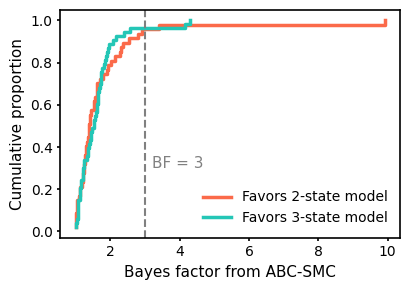

In [5]:
df_abc = pd.read_csv("../../synthetic_data/svm/ABC/100_6_04/tstop_posterior.csv")

bfs = df_abc.p_model_0 / df_abc.p_model_1

bf12 = np.asarray(bfs)

bf_m1 = bf12[bf12 >= 1]          # favors M1 (2-state)
bf_m2 = 1 / bf12[bf12 < 1]       # favors M2 (3-state), converted

import numpy as np
import matplotlib.pyplot as plt

def ecdf(x):
    x = np.sort(np.asarray(x))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

fig, ax = plt.subplots(figsize=(4.2, 3))

x1, y1 = ecdf(bf_m1)
x2, y2 = ecdf(bf_m2)

ax.step(x1, y1, where="post", linewidth=2.5, label="Favors 2-state model",c="#fb6a4a")
ax.step(x2, y2, where="post", linewidth=2.5, label="Favors 3-state model",c="#24C6B6")

# threshold line
ax.axvline(3, linestyle="--", linewidth=1.5, color="gray")
ax.text(3.2, 0.3, "BF = 3", fontsize=11, color="gray")

ax.set_xlabel("Bayes factor from ABC-SMC",fontsize=11)
ax.set_ylabel("Cumulative proportion",fontsize=11)
ax.legend(frameon=False)

ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.tick_params(width=1.2, length=2)
plt.tight_layout()
#plt.savefig("../figs/ecdf_bayes_factor.pdf")